In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
import optuna
import joblib
from sklearn.metrics import mean_absolute_error, mean_squared_error

optuna.logging.set_verbosity(optuna.logging.WARNING)  # quiet output
plt.rcParams['figure.figsize'] = (12, 4)

df = pd.read_parquet('/Users/anish/Documents/demand forcasting time series /data/processed/features.parquet')
print("Shape:", df.shape)
print("Hubs :", df['hub_id'].nunique())

Shape: (66092, 36)
Hubs : 26


In [2]:
cutoff = df['ts'].max() - pd.Timedelta(days=14)

train = df[df['ts'] <= cutoff].copy()
test  = df[df['ts'] >  cutoff].copy()

print("Train:", train['ts'].min(), "→", train['ts'].max(), "|", len(train), "rows")
print("Test :", test['ts'].min(),  "→", test['ts'].max(),  "|", len(test),  "rows")

Train: 2021-01-15 02:00:00 → 2021-04-16 23:00:00 | 57356 rows
Test : 2021-04-17 00:00:00 → 2021-04-30 23:00:00 | 8736 rows


In [3]:
val_cutoff = train['ts'].max() - pd.Timedelta(days=7)

train_fit = train[train['ts'] <= val_cutoff].copy()
val       = train[train['ts'] >  val_cutoff].copy()

print("Train-fit :", train_fit['ts'].min(), "→", train_fit['ts'].max(), "|", len(train_fit), "rows")
print("Validation:", val['ts'].min(),        "→", val['ts'].max(),        "|", len(val),        "rows")

Train-fit : 2021-01-15 02:00:00 → 2021-04-09 23:00:00 | 52988 rows
Validation: 2021-04-10 00:00:00 → 2021-04-16 23:00:00 | 4368 rows


In [4]:
target = 'orders'
exclude = ['ts','hub_name','hub_total_orders','orders']
features = [c for c in df.columns if c not in exclude]

X_train_fit, y_train_fit = train_fit[features], train_fit[target]
X_val,       y_val       = val[features],       val[target]
X_test,      y_test      = test[features],      test[target]

cat_features = ['hub_id','hub_city','hub_state','hub_dominant_segment','hub_dominant_channel']

print("Features:", len(features))
print("X shapes:", X_train_fit.shape, X_val.shape, X_test.shape)

Features: 32
X shapes: (52988, 32) (4368, 32) (8736, 32)


In [5]:
def objective(trial):
    params = {
        'objective': 'poisson',
        'metric': 'mae',
        'verbose': -1,
        'random_state': 42,
        'n_estimators': 3000,
        'learning_rate':      trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves':         trial.suggest_int('num_leaves', 20, 200),
        'max_depth':          trial.suggest_int('max_depth', 4, 12),
        'min_child_samples':  trial.suggest_int('min_child_samples', 10, 100),
        'subsample':          trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':   trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha':          trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':         trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
    }

    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_train_fit, y_train_fit,
        eval_set=[(X_val, y_val)],
        categorical_feature=cat_features,
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )

    preds = np.clip(model.predict(X_val), 0, None)
    return mean_absolute_error(y_val, preds)

In [6]:
study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42)
)

study.optimize(objective, n_trials=30, show_progress_bar=True)

print("\nBest validation MAE:", round(study.best_value, 4))
print("Best hyperparameters:")
for k, v in study.best_params.items():
    print(f"  {k:20s}: {v}")

  0%|          | 0/30 [00:00<?, ?it/s]


Best validation MAE: 1.8407
Best hyperparameters:
  learning_rate       : 0.02014847788415866
  num_leaves          : 114
  max_depth           : 7
  min_child_samples   : 36
  subsample           : 0.8447411578889518
  colsample_bytree    : 0.6557975442608167
  reg_alpha           : 0.0028888383623653178
  reg_lambda          : 0.0067890532716984855


/var/folders/bg/c56hl8bn35xd6x1rywnkcx780000gn/T/ipykernel_1388/4182138229.py:2: ExperimentalWarning: plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  fig1 = optuna.visualization.matplotlib.plot_optimization_history(study)


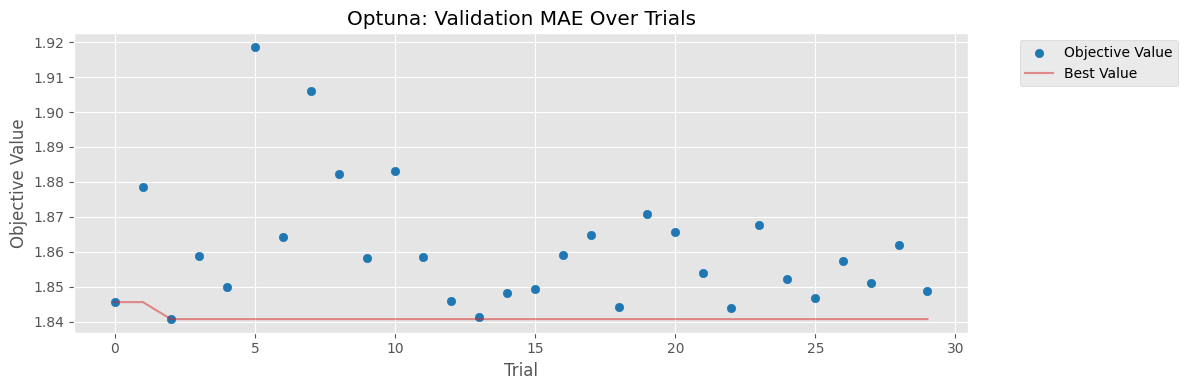

In [7]:
# Optimization history
fig1 = optuna.visualization.matplotlib.plot_optimization_history(study)
plt.title('Optuna: Validation MAE Over Trials')
plt.tight_layout(); plt.show()

/var/folders/bg/c56hl8bn35xd6x1rywnkcx780000gn/T/ipykernel_1388/694156551.py:2: ExperimentalWarning: plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  fig2 = optuna.visualization.matplotlib.plot_param_importances(study)


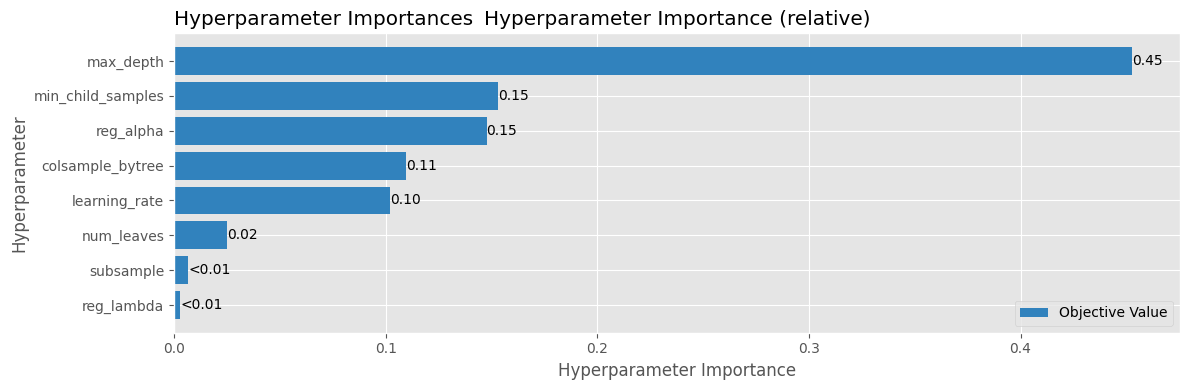

In [8]:
# Hyperparameter importance
fig2 = optuna.visualization.matplotlib.plot_param_importances(study)
plt.title('Hyperparameter Importance (relative)')
plt.tight_layout(); plt.show()

In [9]:
best_params = study.best_params.copy()
best_params['objective']    = 'poisson'
best_params['metric']       = 'mae'
best_params['verbose']      = -1
best_params['random_state'] = 42
best_params['n_estimators'] = 3000

X_train_full, y_train_full = train[features], train[target]

final_model = lgb.LGBMRegressor(**best_params)
final_model.fit(
    X_train_full, y_train_full,
    eval_set=[(X_test, y_test)],
    categorical_feature=cat_features,
    callbacks=[lgb.early_stopping(100), lgb.log_evaluation(200)]
)

Training until validation scores don't improve for 100 rounds
[200]	valid_0's l1: 2.04355
[400]	valid_0's l1: 1.71533
[600]	valid_0's l1: 1.66234
[800]	valid_0's l1: 1.65318
[1000]	valid_0's l1: 1.64539
[1200]	valid_0's l1: 1.64127
[1400]	valid_0's l1: 1.63927
[1600]	valid_0's l1: 1.63615
[1800]	valid_0's l1: 1.63509
[2000]	valid_0's l1: 1.63459
Early stopping, best iteration is:
[1965]	valid_0's l1: 1.63407


LGBMRegressor(colsample_bytree=0.6557975442608167,
              learning_rate=0.02014847788415866, max_depth=7, metric='mae',
              min_child_samples=36, n_estimators=3000, num_leaves=114,
              objective='poisson', random_state=42,
              reg_alpha=0.0028888383623653178, reg_lambda=0.0067890532716984855,
              subsample=0.8447411578889518, verbose=-1)

In [10]:
pred = np.clip(final_model.predict(X_test), 0, None)

final_mae  = mean_absolute_error(y_test, pred)
final_rmse = np.sqrt(mean_squared_error(y_test, pred))
final_wape = np.abs(y_test - pred).sum() / y_test.sum()

print("Tuned LightGBM (test set)")
print(f"  MAE  : {final_mae:.3f}")
print(f"  RMSE : {final_rmse:.3f}")
print(f"  WAPE : {final_wape*100:.2f}%")

Tuned LightGBM (test set)
  MAE  : 1.634
  RMSE : 3.164
  WAPE : 31.96%


In [11]:
# From Notebook 3 (default LightGBM)
default_mae   = 1.649
default_rmse  = 3.195
default_wape  = 32.25

# Baseline (seasonal naive)
baseline_mae  = 2.220
baseline_wape = 43.41

results = pd.DataFrame({
    'Model':    ['Seasonal Naive', 'LightGBM (default)', 'LightGBM (tuned)'],
    'MAE':      [baseline_mae, default_mae, final_mae],
    'RMSE':     [np.nan,       default_rmse, final_rmse],
    'WAPE (%)': [baseline_wape, default_wape, final_wape*100]
}).round(3)

results

,Model,MAE,RMSE,WAPE (%)
0,Seasonal Naive,2.220,NaN,43.410
1,LightGBM (default),1.649,3.195,32.250
2,LightGBM (tuned),1.634,3.164,31.958


In [ ]:
print(f"Tuning improvement over default LightGBM:")
print(f"  MAE  : {(1 - final_mae/default_mae)*100:.2f}%")
print(f"  WAPE : {(1 - final_wape*100/default_wape)*100:.2f}%")

print(f"\nTotal improvement over seasonal-naive baseline:")
print(f"  MAE  : {(1 - final_mae/baseline_mae)*100:.2f}%")
print(f"  WAPE : {(1 - final_wape*100/baseline_wape)*100:.2f}%")ß

Tuning improvement over default LightGBM:
  MAE  : 0.91%
  WAPE : 0.91%

Total improvement over seasonal-naive baseline:
  MAE  : 26.39%
  WAPE : 26.38%


          feature  importance
           hub_id       13380
     roll_mean_24       10377
            lag_1       10083
    roll_mean_168        9295
              day        8688
      roll_std_24        8542
     roll_std_168        7815
         hour_sin        7710
same_hour_2w_mean        7545
           lag_24        7407
             hour        7343
             week        6210
          lag_168        6065
      roll_max_24        5992
          lag_336        5672


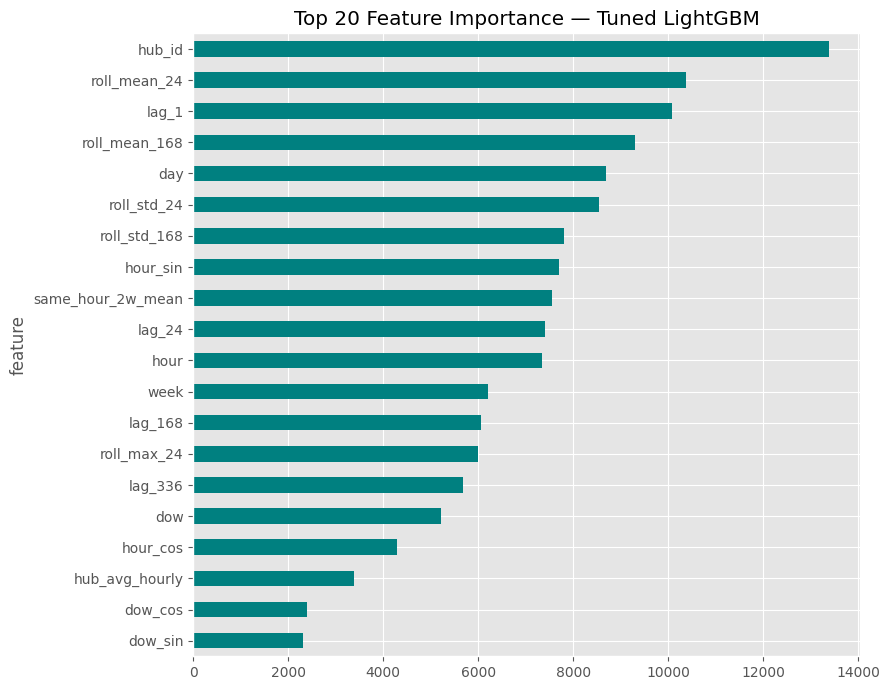

In [13]:
imp = pd.DataFrame({
    'feature': features,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=False)

print(imp.head(15).to_string(index=False))

plt.figure(figsize=(9,7))
imp.head(20).iloc[::-1].plot(kind='barh', x='feature', y='importance',
                             color='teal', legend=False, ax=plt.gca())
plt.title('Top 20 Feature Importance — Tuned LightGBM')
plt.tight_layout(); plt.show()

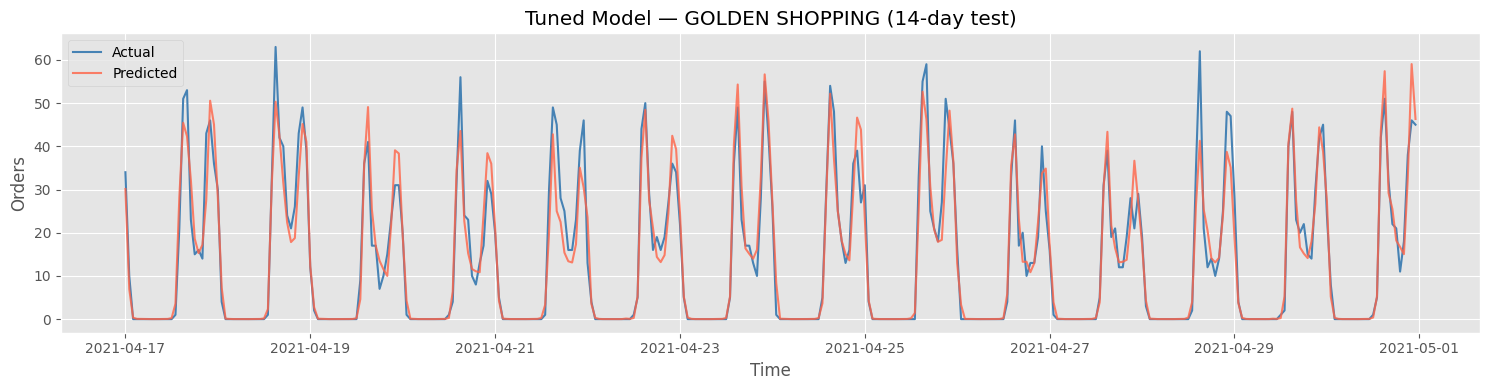

In [14]:
test_eval = test[['hub_id','hub_name','ts','orders']].copy()
test_eval['pred'] = pred

# Pick the hub with the highest total actual orders
top_hub = test_eval.groupby('hub_name', observed=True)['orders'].sum().idxmax()
plot_data = test_eval[test_eval['hub_name'] == top_hub].sort_values('ts')

plt.figure(figsize=(15,4))
plt.plot(plot_data['ts'], plot_data['orders'], label='Actual',    linewidth=1.5, color='steelblue')
plt.plot(plot_data['ts'], plot_data['pred'],   label='Predicted', linewidth=1.5, color='tomato', alpha=0.8)
plt.title(f'Tuned Model — {top_hub} (14-day test)')
plt.xlabel('Time'); plt.ylabel('Orders'); plt.legend(); plt.tight_layout(); plt.show()

In [15]:
test_eval['abs_err'] = (test_eval['orders'] - test_eval['pred']).abs()

per_hub = (test_eval.groupby('hub_name', observed=True)
                    .agg(total_actual=('orders','sum'),
                         total_pred=('pred','sum'),
                         mae=('abs_err','mean'))
                    .sort_values('total_actual', ascending=False))

per_hub['wape_pct'] = ((per_hub['total_actual'] - per_hub['total_pred']).abs()
                       / per_hub['total_actual'] * 100).round(1)

per_hub.round(2)

,total_actual,total_pred,mae,wape_pct
hub_name,,,,
GOLDEN SHOPPING,4537,4454.63,2.48,1.8
SUBWAY SHOPPING,3221,3339.37,2.81,3.7
COFFEE SHOPPING,2843,2687.66,2.24,5.5
PAGODE SHOPPING,2773,2814.49,2.68,1.5
RAP SHOPPING,2443,2384.90,1.83,2.4
GREEN SHOPPING,2378,2278.24,2.06,4.2
PEOPLE SHOPPING,2344,2296.12,1.81,2.0
AVENUE SHOPPING,2338,1991.76,2.16,14.8
HIP HOP SHOPPING,2337,2418.27,2.07,3.5
